#### Import libraries

In [1]:
# NOTE: bramlib is the author's own helper module (used below for the
#       missing-data audit). pandas/glob/os handle file discovery + concatenation.

import pandas as pd
import glob
import os
import bramlib

#### Create functions
create_df: <br>
function to take a csv, get the user id based on the file name and add this back into the pandas dataframe
<br><br>
combine_folder:
<br>Function to combine all files in a single folder into 1 big dataframe, I have added a limit to this function because there are currently about 725.000 files in my dataset, which is too big to experiment on
<br>



In [2]:
# NOTE: Three helpers that fold EdNet's one-CSV-per-student layout into one DataFrame:
#   create_df         - read one student's file; recover user_id from the filename
#                       (e.g. 'u123.csv' -> 123) so identity survives concatenation.
#   combine_folder    - glob + concat every CSV in a folder; `limit` caps the volume
#                       while experimenting (there are ~784k files in full KT1).
#   get_other_folders - optional: merge extra folders on (user_id, timestamp),
#                       label-prefixing new columns. Hook for adding KT2-KT4 later.

def create_df(file, label=None):
    df = pd.read_csv(file)
    user_id = os.path.basename(file).split(".")[0]
    user_id = int(user_id[1:])
    df["user_id"] = user_id

    if label:
        df.columns = [f"{label}_{col}" if col not in ["timestamp", "user_id"] else col for col in df.columns]
    return df

def combine_folder(folder, limit=-1):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    df_list = []
    
    n = 0
    for file in all_files[:limit]:
        df = create_df(file=file)
        df_list.append(df)

        n += 1
        if n % 100 == 0:
            print(f"Currently on:{n}")

    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

def get_other_folders(folders, main_df):

    for folder in folders:
        folder_label = os.path.basename(os.path.normcase(folder)).lower()
        print(f"currently on: {folder_label}")
        
        extra_dfs = []        
        files = glob.glob(os.path.join(folder, "*.csv"))
        valid_users = main_df["user_id"].unique()

        for file in files:
            userc = os.path.basename(file).split(".")[0]
            userc_id = int(userc[1:])

            if userc_id in valid_users:
                df_extra = create_df(file, label=folder_label)
                extra_dfs.append(df_extra)
        
        if extra_dfs:
            temp_df = pd.concat(extra_dfs, ignore_index=True)
            main_df = pd.merge(main_df, temp_df, on=["user_id", "timestamp"], how="outer")

            common = set(main_df["timestamp"]).intersection(set(temp_df["timestamp"]))
            print(len(common))
    return main_df


### Assembling the data
Using the function I had previously made I set a limit of the first 5000 files, this is about 140k rows in my dataframe and a managable 72MB. Using df.head(10), I made sure all data is correctly imported.

In [4]:
# NOTE: limit=25000 -> the run below produced 6,171,161 rows x 6 cols (~282.5 MB).
#       (The markdown above mentions 5000 files / ~140k rows; keep the narrative and
#       the actual limit in sync so reported sizes match.) df.head(10) = import check.

df = combine_folder(r"C:\Users\bramm\S3C2-Data\Student grade project\Data\raw\EdNet-KT1\KT1", 25000)
df.head(10)

Currently on:100
Currently on:200
Currently on:300
Currently on:400
Currently on:500
Currently on:600
Currently on:700
Currently on:800
Currently on:900
Currently on:1000
Currently on:1100
Currently on:1200
Currently on:1300
Currently on:1400
Currently on:1500
Currently on:1600
Currently on:1700
Currently on:1800
Currently on:1900
Currently on:2000
Currently on:2100
Currently on:2200
Currently on:2300
Currently on:2400
Currently on:2500
Currently on:2600
Currently on:2700
Currently on:2800
Currently on:2900
Currently on:3000
Currently on:3100
Currently on:3200
Currently on:3300
Currently on:3400
Currently on:3500
Currently on:3600
Currently on:3700
Currently on:3800
Currently on:3900
Currently on:4000
Currently on:4100
Currently on:4200
Currently on:4300
Currently on:4400
Currently on:4500
Currently on:4600
Currently on:4700
Currently on:4800
Currently on:4900
Currently on:5000
Currently on:5100
Currently on:5200
Currently on:5300
Currently on:5400
Currently on:5500
Currently on:5600
C

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,1565096190868,1,q5012,b,38000,1
1,1565096221062,2,q4706,c,24000,1
2,1565096293432,3,q4366,b,68000,1
3,1565096339668,4,q4829,a,42000,1
4,1565096401774,5,q6528,b,59000,1
5,1565096463370,6,q4793,a,58000,1
6,1565096501746,7,q6488,a,35000,1
7,1565097101361,8,q356,b,23000,1
8,1565097171393,9,q1382,c,22000,1
9,1565097240758,10,q830,b,25000,1


df.info() gives important information about the dataset, this includes the types pandas has inferred from the csv and the size of the dataset. Knowing the types of the dataset is important for knowing which functions to apply later on, and what I can and cannot combine.

In [5]:
# NOTE: dtypes decide what is valid downstream. question_id & user_answer are objects
#       (strings); the analysis notebook casts question_id to int to join the key table.

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6171161 entries, 0 to 6171160
Data columns (total 6 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   timestamp     int64 
 1   solving_id    int64 
 2   question_id   object
 3   user_answer   object
 4   elapsed_time  int64 
 5   user_id       int64 
dtypes: int64(4), object(2)
memory usage: 282.5+ MB


This analyze_missing_data() is a function I made in my previous semester 

--- Missing Data Report for df ---
Total Data Points: 37026966
Total Missing Data Points: 854
Overall Missing Data: 0.00%

Missing Data Per Column (%):


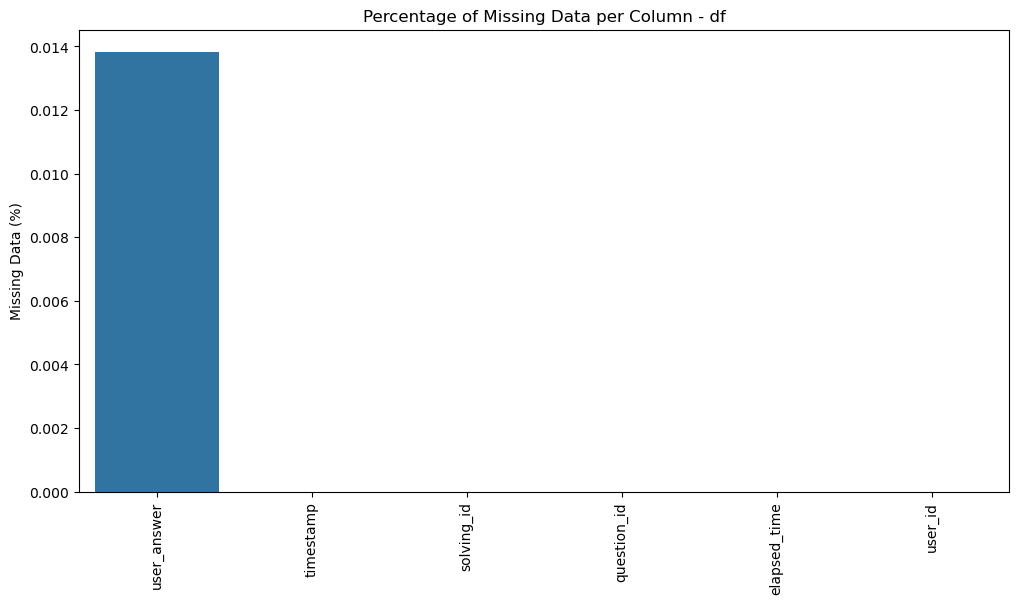

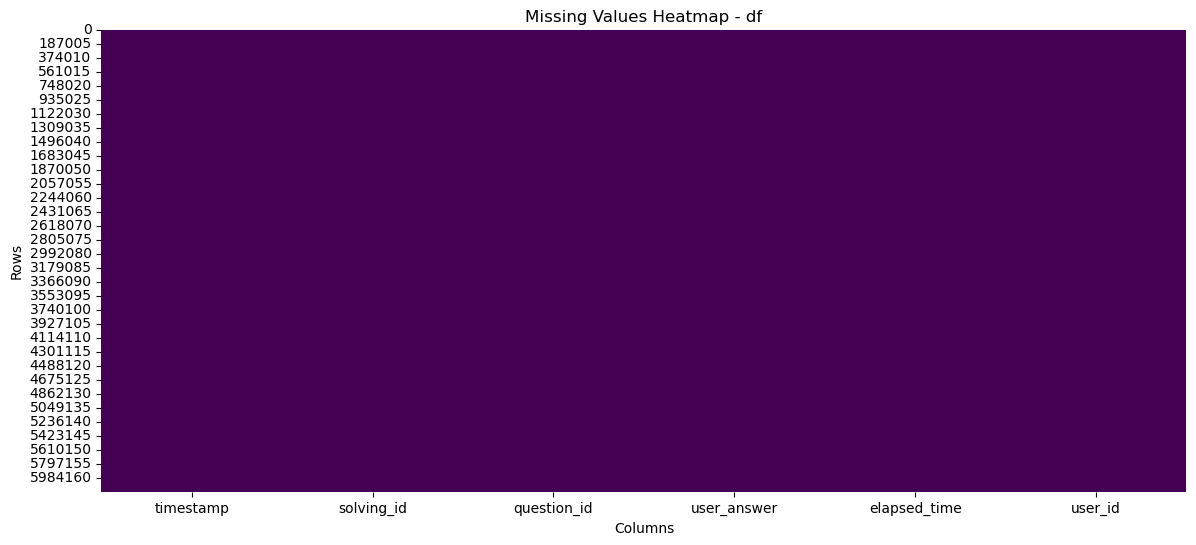

In [6]:
# NOTE: Reports 854 / 37,026,966 missing (~0.00%). Effectively complete -> no
#       imputation needed before modelling.

bramlib.analyze_missing_data(df)

In [7]:
# NOTE: Hand-off file for the modelling notebooks. Heads-up: one analysis notebook
#       reads '5kfiles_kt1.csv' instead -> use ONE extract end-to-end for comparable counts.

df.to_csv("25kfiles_kt1.csv")